# Amna Kauser 

# Task: 3 Customer Churn Prediction (Bank Customers)

In [2]:
# importing libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn 
import sklearn as sk
from sklearn.preprocessing import LabelEncoder


In [3]:
churn=pd.read_csv('C:/Users/User/Downloads/archive (3)/Churn_Modelling.csv')

In [4]:
churn.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
churn.shape

(10000, 14)

# Clean and Prepare the Dataset

In [6]:
#chceking for missing values
churn.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
# Check duplicates
print("\nDuplicates:", churn.duplicated().sum())
 
# Check churn distribution
print("\nChurn Count:\n", churn['Exited'].value_counts())
 
# Drop unnecessary columns
churn.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True, errors='ignore')
 
# Drop duplicates if any
churn.drop_duplicates(inplace=True)
 


Duplicates: 0

Churn Count:
 Exited
0    7963
1    2037
Name: count, dtype: int64


In [7]:
# Check dataset after cleaning
print("Shape after cleaning:", churn.shape)
print(churn.head())

Shape after cleaning: (10000, 14)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3       

# Encode categorical features such as geography and gender.

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Label Encoding for Gender (only 2 values: Male/Female)
churn['Gender'] = le.fit_transform(churn['Gender'])

# One Hot Encoding for Geography (3 values: France/Spain/Germany)
churn = pd.get_dummies(churn, columns=['Geography'], drop_first=True)

print("After Encoding:")
print(churn.head())
print(churn.shape)

After Encoding:
   RowNumber  CustomerId   Surname  CreditScore  Gender  Age  Tenure  \
0          1    15634602  Hargrave          619       0   42       2   
1          2    15647311      Hill          608       0   41       1   
2          3    15619304      Onio          502       0   42       8   
3          4    15701354      Boni          699       0   39       1   
4          5    15737888  Mitchell          850       0   43       2   

     Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0       0.00              1          1               1        101348.88   
1   83807.86              1          0               1        112542.58   
2  159660.80              3          1               0        113931.57   
3       0.00              2          0               0         93826.63   
4  125510.82              1          1               1         79084.10   

   Exited  Geography_Germany  Geography_Spain  
0       1              False            False  
1   

# Trian a Classification Model 

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Drop any remaining string columns before training
churn.drop(columns=['Surname', 'CustomerId'], inplace=True, errors='ignore')

# Features & Target
X = churn.drop(columns=['Exited'])
y = churn['Exited']

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X.dtypes)

# Train
clf = DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

print("Model Trained Successfully!")

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

RowNumber              int64
CreditScore            int64
Gender                 int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Geography_Germany       bool
Geography_Spain         bool
dtype: object
Model Trained Successfully!
Accuracy: 0.857


# Analyze feature importance to understand what influences churn.

Feature Importances:
 Age                  0.408288
NumOfProducts        0.360898
IsActiveMember       0.098875
Balance              0.075686
Geography_Germany    0.040402
EstimatedSalary      0.008015
Gender               0.006105
Tenure               0.001732
RowNumber            0.000000
CreditScore          0.000000
HasCrCard            0.000000
Geography_Spain      0.000000
dtype: float64


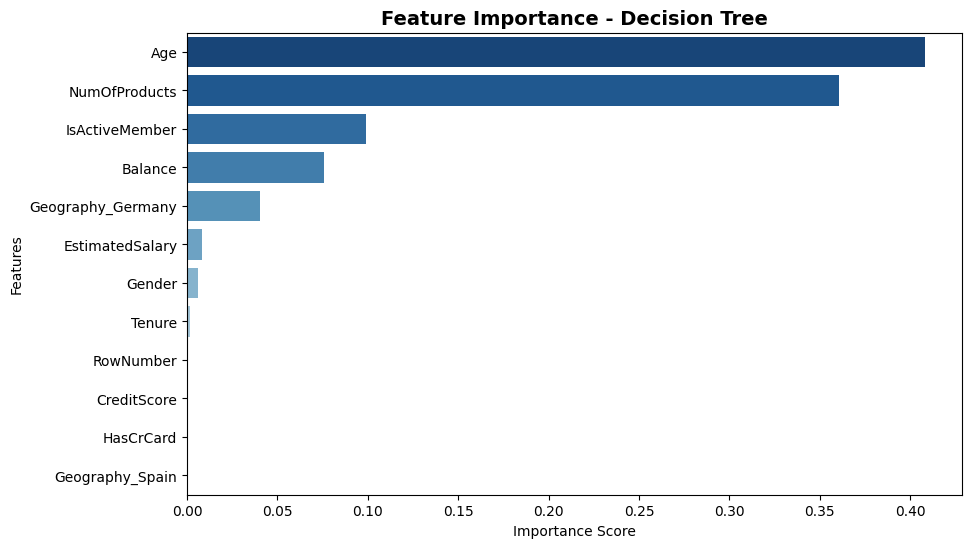

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
feature_importance = pd.Series(clf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print("Feature Importances:\n", feature_importance)

# Plot
plt.figure(figsize=(10, 6))
sn.barplot(x=feature_importance.values, y=feature_importance.index, hue=feature_importance.index, palette='Blues_r')
plt.title('Feature Importance - Decision Tree', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

Top factors — Age (0.41) and NumOfProducts (0.36) are the most important features in predicting customer churn, meaning older customers and those with more products are the most likely to leave the bank.
Low impact features — Tenure, CreditScore, HasCrCard, and Geography_Spain have almost zero importance, meaning they have no effect on whether a customer churns or not.